Working through examples in Chapter 1: Singular Value Decomposition

In [63]:
# Section 5.1
# Computing SVD

import numpy as np
import pandas as pd
X = np.random.rand(5, 3) #I'm creating a random 5x3 matrix
U, S, VT = np.linalg.svd(X, full_matrices = True) #Setting full_matrices to False would give us a reduced SVD
UHat, SHat, VTHat = np.linalg.svd(X, full_matrices = False) #Here's our aforementioned Economy SVD

In [64]:
print(f"{U} \n")
print(f"{S} \n")
print(VT)

[[-0.19028191  0.19264027 -0.88217585 -0.26437494 -0.28027519]
 [-0.45387178 -0.52670534 -0.11888187  0.64686197 -0.28985958]
 [-0.51337658 -0.21204692  0.37634524 -0.63516445 -0.38263687]
 [-0.49708427  0.78450257  0.20814761  0.30050449 -0.06192384]
 [-0.49713672 -0.15831306 -0.15057126 -0.13393526  0.82896423]] 

[2.508712   0.43679616 0.30463797] 

[[-0.53849178 -0.72152232 -0.43523803]
 [ 0.13719533 -0.58470512  0.79956073]
 [ 0.83138682 -0.37084426 -0.4138484 ]]


In [65]:
print(f"{UHat} \n")
print(f"{SHat} \n")
print(VTHat)

[[-0.19028191  0.19264027 -0.88217585]
 [-0.45387178 -0.52670534 -0.11888187]
 [-0.51337658 -0.21204692  0.37634524]
 [-0.49708427  0.78450257  0.20814761]
 [-0.49713672 -0.15831306 -0.15057126]] 

[2.508712   0.43679616 0.30463797] 

[[-0.53849178 -0.72152232 -0.43523803]
 [ 0.13719533 -0.58470512  0.79956073]
 [ 0.83138682 -0.37084426 -0.4138484 ]]


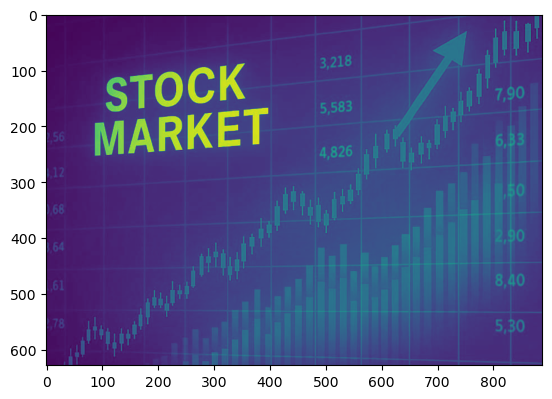

In [66]:
# Section 5.2 SVD Image Compression

#First, we load the image
import matplotlib 
import matplotlib.pyplot as plt

from matplotlib.image import imread
A = imread(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\stock_market.jpg")
X = np.mean(A, -1); #Converting to grayscale
img = plt.imshow(X)

In [67]:
#import os

#print(os.getcwd())
#print(os.listdir())

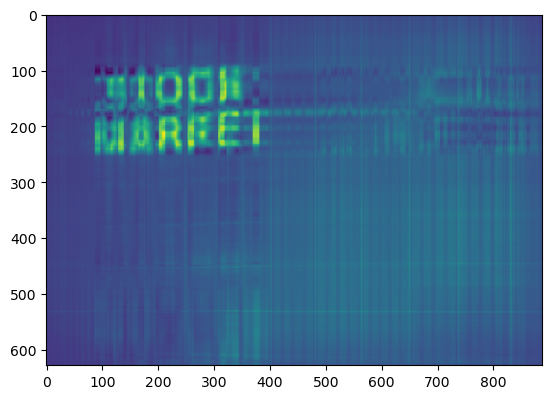

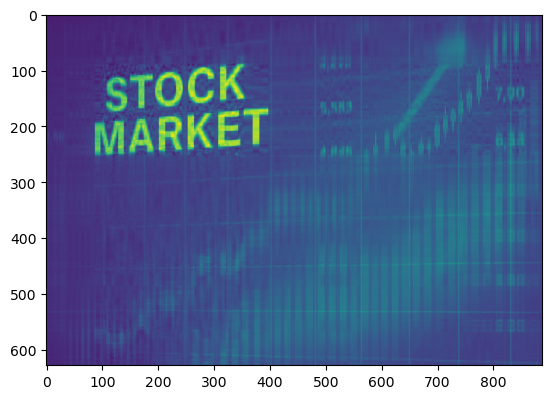

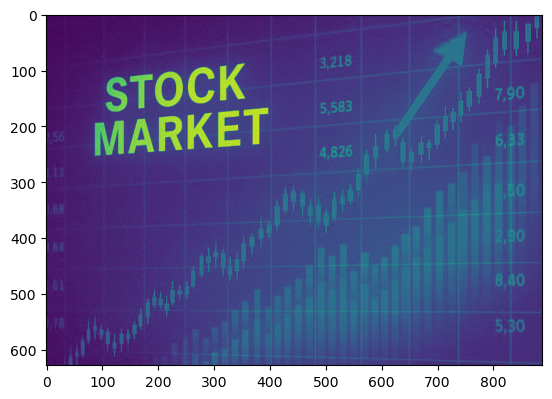

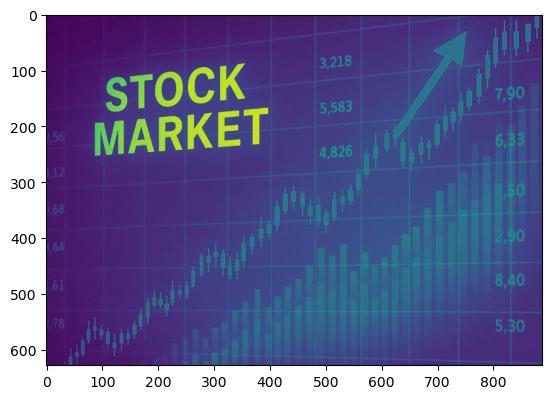

In [68]:
#Take SVD
U, S, VT = np.linalg.svd(X, full_matrices=False)
S = np.diag(S)

#Approximate matrix with truncated SVD for various r

for r in (5, 20, 100, 200):
    Xapprox = U[:, :r] @ S[0:r, :r] @ VT[:r, :]
    img = plt.imshow(Xapprox)
    plt.show()

<bound method Axes.set of <Axes: xlabel='Rank', ylabel='Cumulative Sum'>>

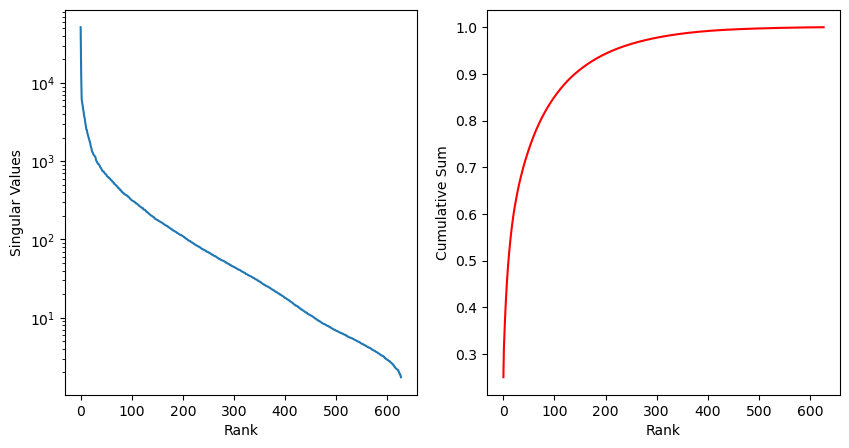

In [69]:
#Plot singular values and cumulative sum
#Create 2 graphs
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].semilogy(np.diag(S)) #Convenient for converting to log scale graph
ax[0].set_ylabel('Singular Values')
ax[0].set_xlabel('Rank')

ax[1].plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)), color = 'red')
ax[1].set_ylabel('Cumulative Sum')
ax[1].set_xlabel('Rank')
ax[1].set

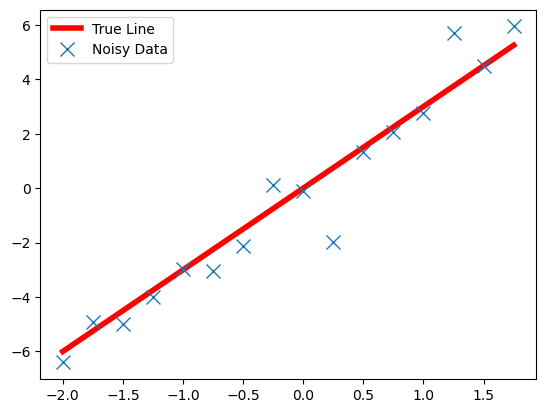

In [106]:
#Section 1.4 Pseudo-inverse
#Least-Squares fit of noisy data in fig 1.9

x = 3 #This is the true slope of the line

a = np.arange(-2, 2, 0.25)
a = a.reshape(-1, 1)
b = x*a + np.random.randn(*a.shape) #Adding noise to the data to simulate real-world data

plt.plot(a, x*a, 'r-', label = 'True Line', linewidth = 4)

plt.plot(a, b, 'x', label = 'Noisy Data', markersize = 10, linewidth = 6)

plt.legend()

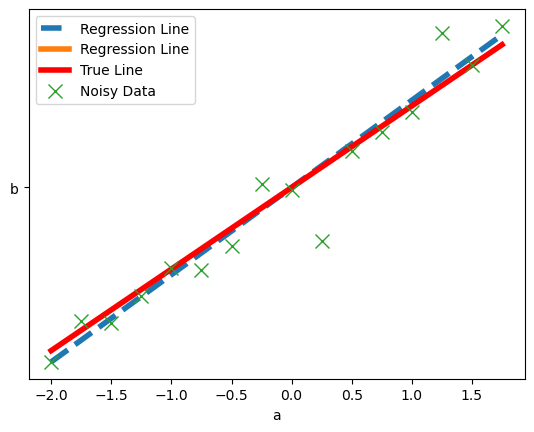

In [108]:
#Now we're going to use a least squares approximation with SVD and see how it matches up with the true line

U, S, VT = np.linalg.svd(a, full_matrices=False)
xtilde = VT.T @ np.linalg.inv(np.diag(S)) @ U.T @ b #Least Square fit using inverse solution

plt.plot(a, xtilde*a, '--', 'b', label = 'Regression Line', linewidth = 4)

#I'm now overlaying the previous graph on top just for a visual comparison of the two lines

plt.plot(a, x*a, 'r-', label = 'True Line', linewidth = 4)
plt.plot(a, b, 'x', label = 'Noisy Data', markersize = 10, linewidth = 6)

plt.xlabel('a')

plt.legend()
#You can see that the regression line is a good approximation of the true line, even with the noise in the data. This demonstrates the power of SVD.

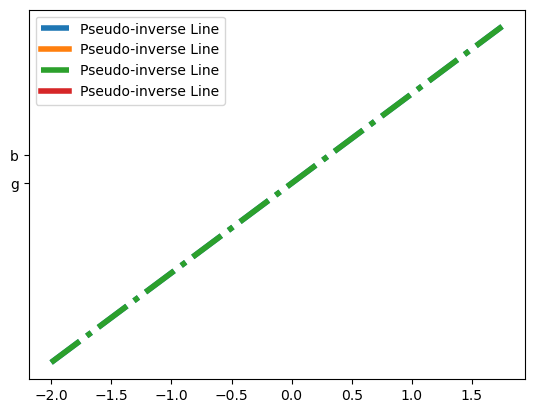

In [109]:
#Alternate least squares formulation

#Note, if x is a 1x1 matrix, then dot product and matrix multiplication are equivalent here

xtilde2 = np.linalg.pinv(a) @ b #Least Square fit using pseudo-inverse

plt.plot(a, xtilde2*a, '-.', 'g', label = 'Pseudo-inverse Line', linewidth = 4)
plt.plot(a, a @ xtilde2, '-.', 'b', label = 'Pseudo-inverse Line', linewidth = 4)

plt.legend()

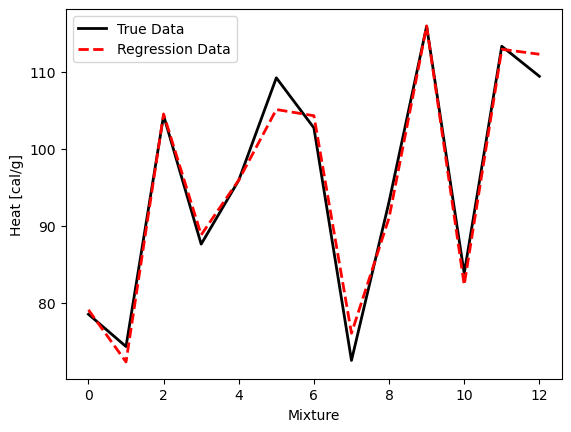

In [110]:
#Multiple linear regression for cement data

#Load dataset
A = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\hald_ingredients.csv", header = None)
b = pd.read_csv(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\hald_heat.csv", header = None)

#Using good old SVD to solve Ax = b

U, S, VT = np.linalg.svd(A, full_matrices = 0)
#x = VT.T @ np.linalg.inv(np.diag(S)) @ U.T @ b
x = np.linalg.pinv(A) @ b #pinv is much more convenient than writing ou the whole inverse solution

plt.plot(b, 'k', linewidth = 2, label = 'True Data')
plt.plot(A @ x, 'r--', linewidth = 2, label = 'Regression Data')

plt.xlabel('Mixture')
plt.ylabel('Heat [cal/g]')

plt.legend()

In [ ]:
#Example 2: Determining significance of factors
    #Boston Housing Market

